In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Mutations from SadA WT

In [2]:
from rosetta_db import get_sqlite_dbcon
db_con = get_sqlite_dbcon(parent="WT")
df = pd.read_sql("select * from docked_scores", db_con)
#df = pd.read_sql("select * from relaxed_scores", db_con)

In [3]:
df["dist_wt"] = df.variant.str.count("\.") + 1

In [4]:
df.head()

,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,dslf_ca_dih,...,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description,variant,dist_wt
0,-877.100,-31.0,0.706,0.0,0.0,0.0,-26.0,0.983,0.0,0.0,...,-7.346,1.0,48.260,-39.465,1.092,-45.15,-26.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0052,D157G.I71V.R172H.F152L.I38V.Q233R.F261L.V38I.R48C,9
1,-883.151,-30.0,0.744,0.0,0.0,0.0,-27.0,1.257,0.0,0.0,...,-6.493,1.0,49.442,-41.111,1.257,-42.55,-27.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0042,D157G,1
2,-878.427,-29.0,0.660,0.0,0.0,0.0,-29.0,0.909,0.0,0.0,...,-11.721,1.0,49.369,-39.094,1.197,-40.34,-29.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0077,D157G.I71V.R172H.N65D,4
3,-877.227,-31.0,0.708,0.0,0.0,0.0,-28.0,0.860,0.0,0.0,...,-10.863,1.0,48.495,-40.860,1.263,-42.99,-28.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0087,D157G.I71V.R172H.F152L,4
4,-872.393,-29.0,0.810,0.0,0.0,0.0,-28.0,0.660,0.0,0.0,...,-10.795,1.0,48.900,-41.013,1.196,-45.85,-28.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0080,D157G.I71V.R172H.F152L.I38V.Q233R.F261L,7


In [5]:
campaign1_muts = [
    'D157G.I71V.R172H.F152L.I38V.Q233R.F261L',
    'D157G.I71V.R172H.F152L.I38V.Q233R.F261L.V38I.R48C',
    'D157G.I71V.R172H.F152L',
    'D157G.I71V.R172H.N65D',
    'D157G.I71V.R172H',
    'D157G.I71V',
    'D157G'
]

In [6]:
df["variant_type"] = pd.Categorical(df.variant.isin(campaign1_muts)).rename_categories(["random", "campaign1"])
df_random = df[df.variant_type == "random"]
df_campaign1 = df[df.variant_type == "campaign1"]

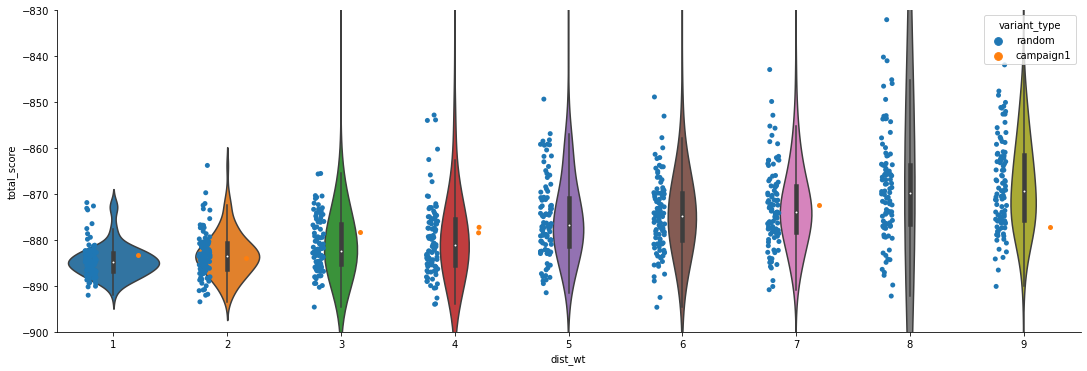

In [7]:
#sns.catplot(y="total_score", x="dist_wt", data=df, aspect=3, kind="box")
#plt.figure(figsize=(12, 4))
g = sns.catplot(y="total_score", x="dist_wt", kind="violin", data=df_random, aspect=3, alpha=0.4)
sns.stripplot(y="total_score", x="dist_wt", hue="variant_type",
              data=df, ax=g.ax, dodge=True)


plt.ylim(bottom=-900, top=-830)
plt.subplots_adjust()

## Mutations from 2D parent

In [8]:
from rosetta_db import get_sqlite_dbcon
db_con = get_sqlite_dbcon(parent="2D")
df = pd.read_sql("select * from docked_scores", db_con)
#df = pd.read_sql("select * from relaxed_scores", db_con)

In [9]:
df["dist_wt"] = df.variant.str.count("\.") + 1
df.head()

,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,dslf_ca_dih,...,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description,variant,dist_wt
0,-894.048,-31.0,0.790,0.0,0.0,0.0,-29.0,0.724,0.0,0.0,...,-10.495,1.0,48.539,-42.449,1.057,-44.53,-29.0,SadA_NSLeu_2D_0001_0001_0085,F240S,1
1,-891.075,-31.0,0.766,0.0,0.0,0.0,-29.0,1.075,0.0,0.0,...,-11.265,1.0,50.349,-41.727,1.029,-45.96,-29.0,SadA_NSLeu_2D_0001_0001_0010,A187R.V39N.F62K,3
2,-885.675,-31.0,0.808,0.0,0.0,0.0,-29.0,0.719,0.0,0.0,...,-9.093,1.0,48.736,-41.179,1.080,-39.69,-29.0,SadA_NSLeu_2D_0001_0001_0075,D190I.Q236I.T254S.E134P.E208C.G180R.A69W,7
3,-892.496,-29.0,0.766,0.0,0.0,0.0,-29.0,0.775,0.0,0.0,...,-12.745,1.0,48.305,-43.662,1.040,-40.86,-29.0,SadA_NSLeu_2D_0001_0001_0054,H3W.V142G.T254P.F150W.A18R.G79Q.A15C.A187T.I248R,9
4,-902.430,-31.0,0.786,0.0,0.0,0.0,-30.0,0.767,0.0,0.0,...,-7.656,1.0,48.245,-42.532,1.132,-47.13,-30.0,SadA_NSLeu_2D_0001_0001_0063,F97L.H210R,2


In [10]:
parent_2d_eppcr_df = pd.read_csv("../output/2D/azid_model_sequences.csv")
eppcr_seqs = parent_2d_eppcr_df[["category", "response"]].copy()
eppcr_seqs["variant"] = parent_2d_eppcr_df.mutants_in_seq.str.replace(";", ".")
eppcr_seqs.head()

,category,response,variant
0,High Azidation,3,D65N.F152L
1,High Azidation,3,D65N.G192S
2,High Azidation,3,NaN
3,High Azidation,3,A211T.K227I
4,High Azidation,3,D65N.F152L.K227I


In [11]:
df = pd.merge(df, eppcr_seqs, how="left")

In [12]:
variant_type = df.category.astype(str)
variant_type[variant_type == "nan"] = "random"
df["variant_type"]  = pd.Categorical(variant_type, categories=
    ['High Azidation', 'Parent Azidation', 'Low Azidation','No Azidation', 'random'])


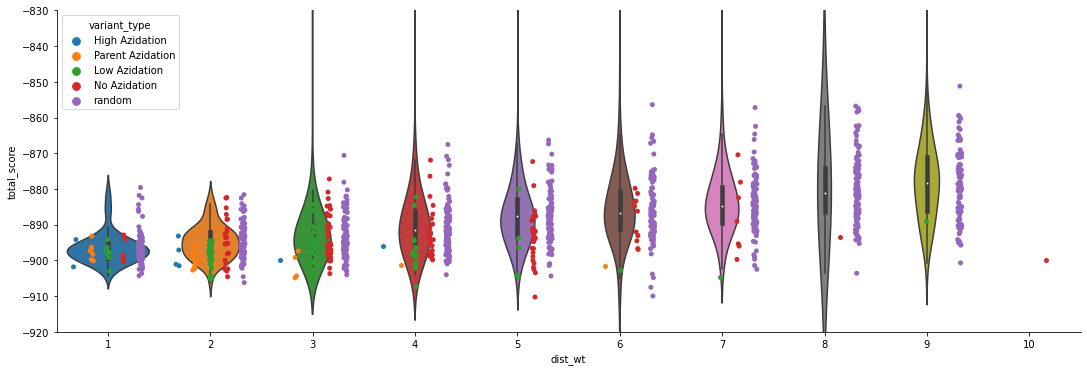

In [13]:
#sns.catplot(y="total_score", x="dist_wt", data=df, aspect=3, kind="box")
#plt.figure(figsize=(12, 4))
g = sns.catplot(y="total_score", x="dist_wt", kind="violin", data=df[df.variant_type == "random"], aspect=3, alpha=0.4)
sns.stripplot(y="total_score", x="dist_wt", hue="variant_type",
              data=df, ax=g.ax, dodge=True)


plt.ylim(bottom=-920, top=-830)
plt.subplots_adjust()

### Correlation between Rosetta score and azidation bin

In [14]:
import scipy.stats

In [15]:
df_eppcr = df[df.variant_type != "random"]

In [16]:
scipy.stats.spearmanr(df_eppcr.response.astype(int), df_eppcr.total_score)

SpearmanrResult(correlation=-0.4121787314503803, pvalue=7.739971411015518e-12)

In [17]:
scipy.stats.kendalltau(df_eppcr.response.astype(int), df_eppcr.total_score)

KendalltauResult(correlation=-0.32151554976868524, pvalue=6.380216126396338e-11)